# 실전 대비 주요 시각화 그래프 정리

In [76]:
from pathlib import Path
parent_path = Path.cwd().parent # 절대경로의 부모 디렉토리
parent_path = parent_path.parent
file_path = parent_path / "04_Resources" / "Dataset" 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic') # 라이브러리 제작자가 올려둔 파일임

matplotlib은 모든 파이썬 시각화 라이브러리의 근간임. seaborn은 matplotlib을 더 쉽고 예쁘게 쓸 수 있게 개량한 라이브러리임.
기본적으로 seaborn을 사용하고 정교하게 다듬을 필요성이 있을 때 matplotlib을 사용하는게 좋음

## 수치형 데이터 시각화

In [14]:
titanic.head() # 데이터 구성 살펴보기

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


age, fate 등의 수치형 데이터가 있음
seaborn이 제공하는 주요 분포도 함수
histplot()
kdeplot()
displot()
rugplot()
를 이용해 표현해보자

### 1. histplot() 히스토그램

<Axes: xlabel='age', ylabel='Count'>

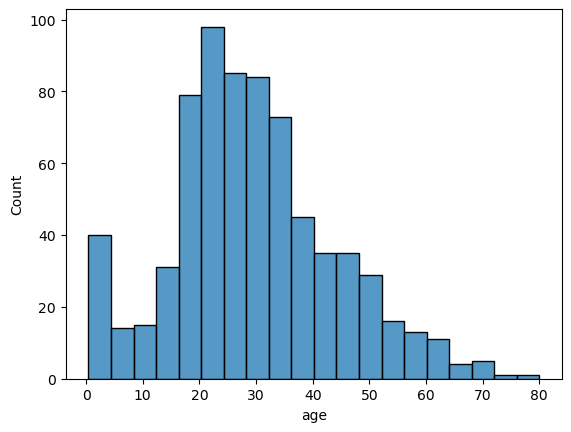

In [19]:
sns.histplot(data=titanic, x='age') # 기본형 - dataset과 x축 지정

<Axes: xlabel='age', ylabel='Count'>

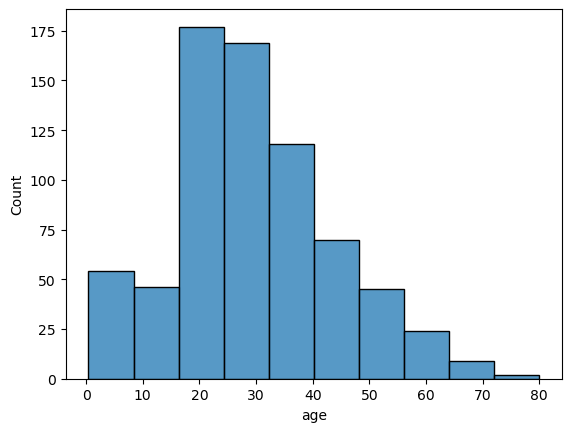

In [18]:
sns.histplot(data=titanic, x='age', bins=10) # x축 구간 10개로 나누기

<Axes: xlabel='age', ylabel='Count'>

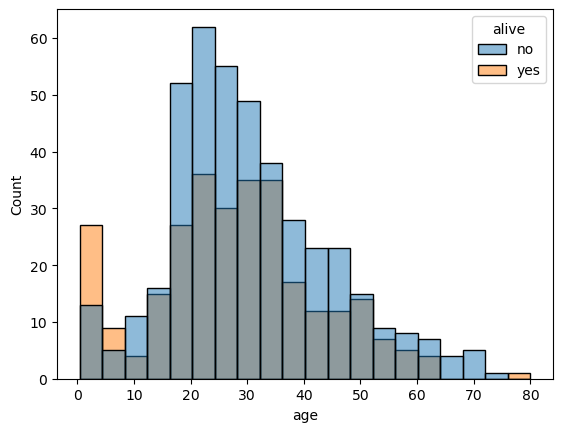

In [21]:
sns.histplot(data=titanic, x='age', hue='alive') # 특정 범주별로 구분하기
# alive의 두 범주가 서로 포개져서 나타난다

<Axes: xlabel='age', ylabel='Count'>

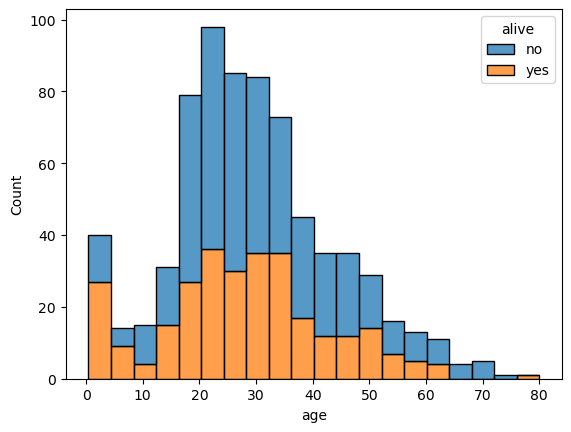

In [23]:
sns.histplot(data=titanic, x='age', hue='alive', multiple='stack') # 포개지 않고 누적해서 표현해보기

### 2. kdeplot() 커널밀도추정 함수 그래프

<Axes: xlabel='age', ylabel='Density'>

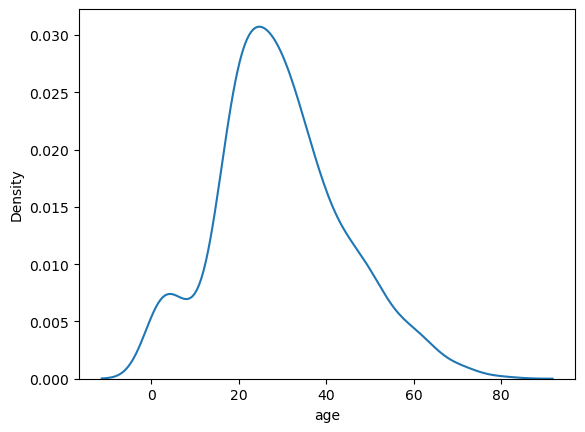

In [26]:
sns.kdeplot(data=titanic, x='age') # 히스토그램을 매끄럽게 연결한 모양. 파라미터 hue, multiple은 그대로 쓸 수 있다

### 3. displot() 분포도

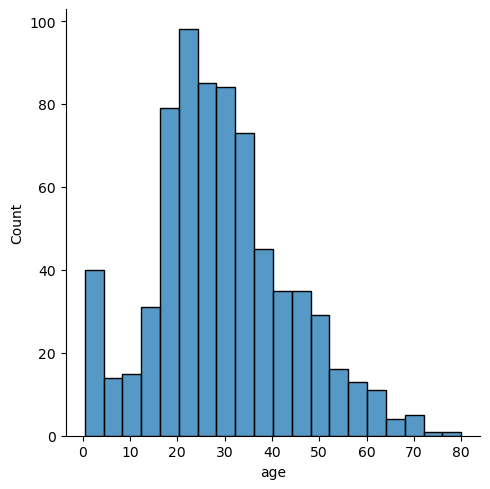

In [28]:
sns.displot(data=titanic, x='age') 
# 수치형 데이터 하나의 분포를 나타냄.
# 파라미터 조정에 따라 histplot과 kdeplot 모두 표현 가능하기 때문에 자주 사용한다.

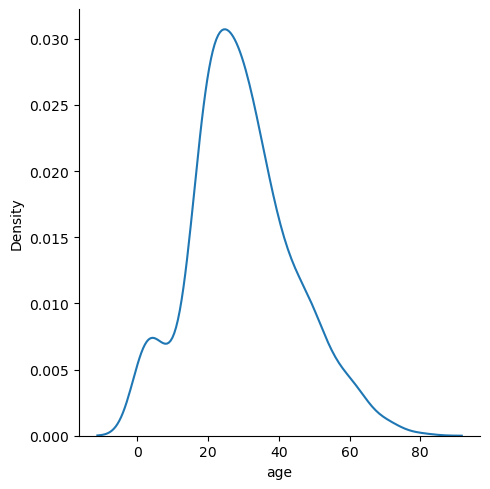

In [ ]:
sns.displot(data=titanic, x='age', kind='kde') # 종류를 커널밀도함수로

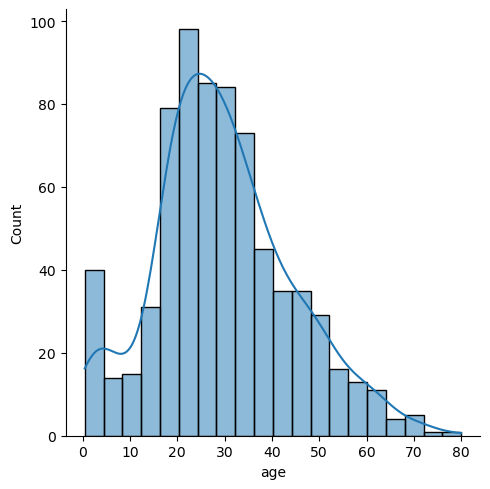

In [30]:
sns.displot(data=titanic, x='age', kde=True) # 히스토그램과 커널밀도함수 그래프 동시에 표현

### 4. rugplot() 주변분포(marginal distribution)

<Axes: xlabel='age', ylabel='Density'>

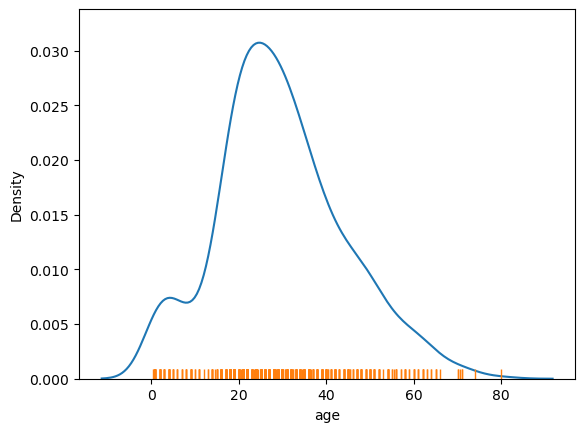

In [32]:
# 단독 사용보다는 다른 분포 그래프로 동시에 사용함
sns.kdeplot(data=titanic, x='age')
sns.rugplot(data=titanic, x='age') # age의 단일 피처가 어떻게 분포돼 있는 지 작은 선분(러그)로 표시

## 범주형 데이터 시각화

### 1. barplot 막대그래프

<Axes: xlabel='class', ylabel='fare'>

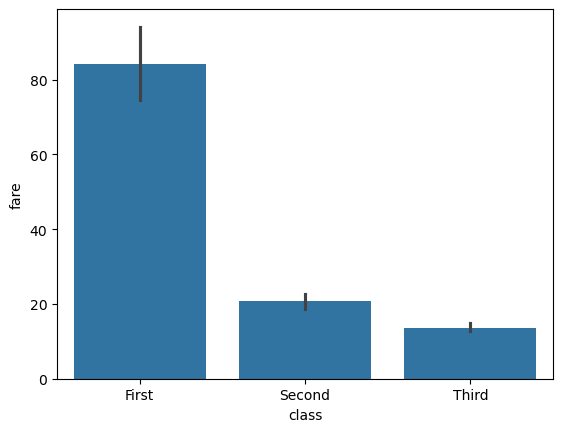

In [62]:
sns.barplot(x='class', y='fare', data=titanic) # 샘플링한 데이터의 평균과 신뢰구간.
# 원본 데이터가 아니라 샘플링한 데이터다
# estimator=np.max  median  min  으로 변경 가능

### 2. pointplot() 포인트플롯

<Axes: xlabel='class', ylabel='fare'>

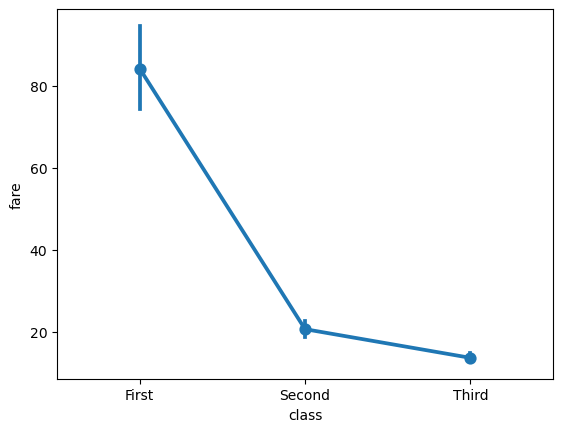

In [ ]:
sns.pointplot(x='class', y='fare', data=titanic) # barplot과 형태만 다르고 같은 정보 출력

### 3. boxplot() 박스플롯

boxplot은 5가지 요약 수치를 제공함
사분위수: Q1, Q2, Q3
IQR: Q3 - Q1
이상치 범위 max: Q3 + 1.5*IQR
            min: Q1 - 1.5*IQR


<Axes: xlabel='class', ylabel='age'>

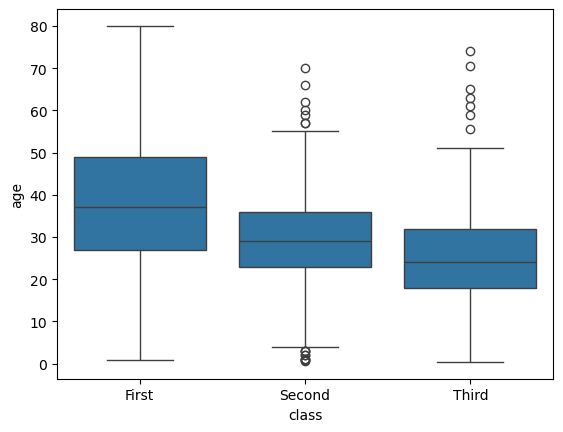

In [54]:
sns.boxplot(x='class', y='age', data=titanic)

### 4. violinplot() 바이올린 플롯

<Axes: xlabel='class', ylabel='age'>

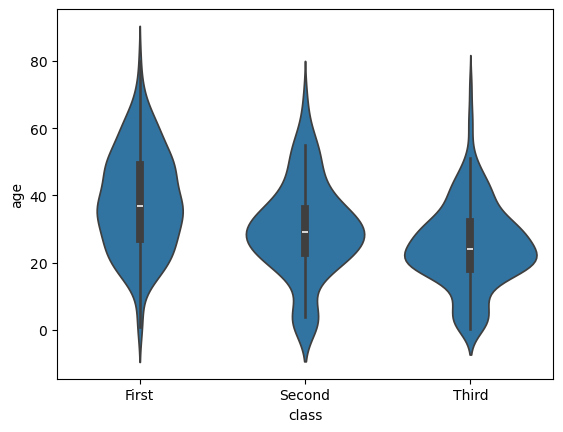

In [56]:
sns.violinplot(x='class', y='age', data=titanic) # 박스플롯과 커널밀도추정 함수 그래프를 섞은 모양

<Axes: xlabel='class', ylabel='age'>

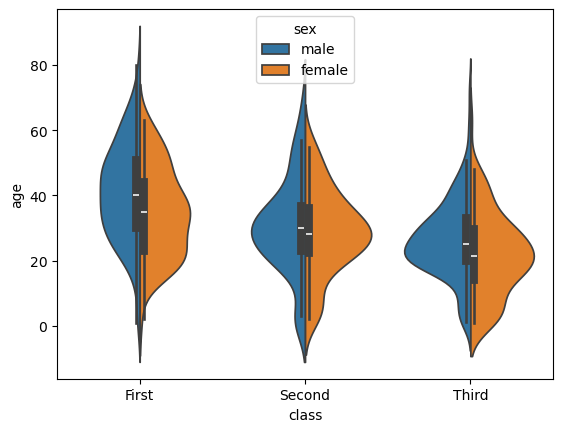

In [58]:
# hue 추가해보기
sns.violinplot(x='class', y='age', data=titanic, hue='sex', split=True)

### 5. countplot() 카운트플롯

<Axes: xlabel='class', ylabel='count'>

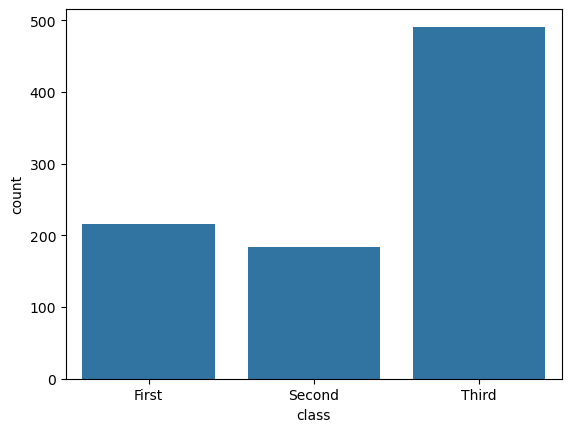

In [59]:
sns.countplot(x='class', data=titanic) # class 별 데이터 개수 세기

<Axes: xlabel='count', ylabel='class'>

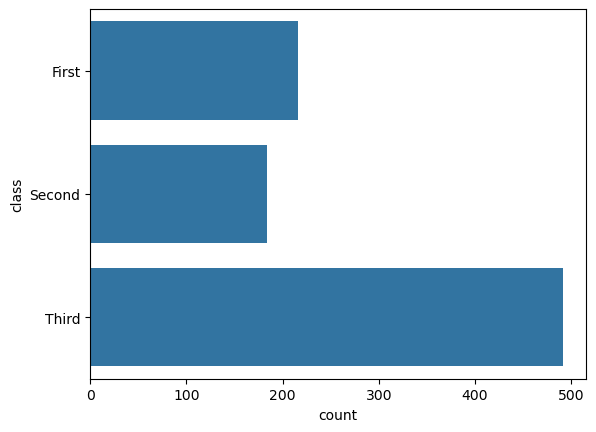

In [61]:
sns.countplot(y='class', data=titanic) # 방향 바꾸기

### 6. pie() 파이그래프

seaborn에는 없기 때문에 matplotlib 이용

([<matplotlib.patches.Wedge at 0x1ebc03ab750>,
 [Text(1.0461621649530053, 0.3399187029582827, 'A'),
  Text(-0.8899188931847394, 0.6465635031092063, 'B'),
  Text(0.6465640158668551, -0.8899185206445168, 'C')],
 [Text(0.5706339081561846, 0.18541020161360874, '10.0%'),
  Text(-0.48541030537349417, 0.35267100169593063, '60.0%'),
  Text(0.3526712813819209, -0.4854101021697364, '30.0%')])

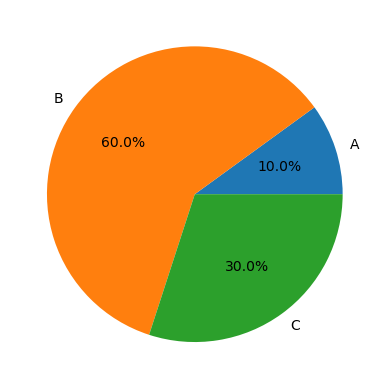

In [64]:
x = [10, 60, 30]                  # 비율
labels = ['A', 'B', 'C']          # 라벨
plt.pie(x=x, labels=labels, autopct='%.1f%%')

## 데이터 관계 시각화

관계도를 통해 데이터 사이의 관계성을 알아보자

### 1. heatmap()

In [65]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [66]:
flights_pivot = flights.pivot(index='month', columns='year', values='passengers')
flights_pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


<Axes: xlabel='year', ylabel='month'>

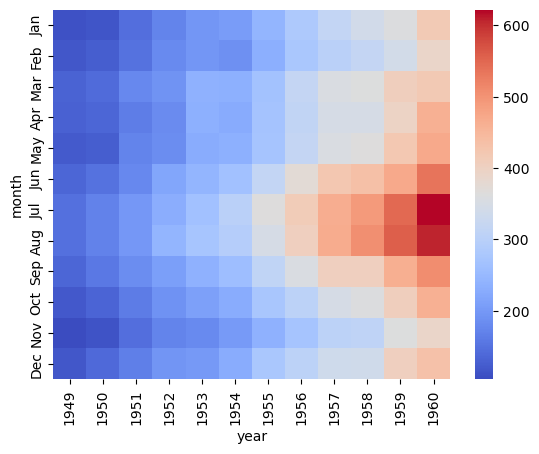

In [69]:
sns.heatmap(data=flights_pivot, cmap='coolwarm')

### 2. lineplot()

<Axes: xlabel='year', ylabel='passengers'>

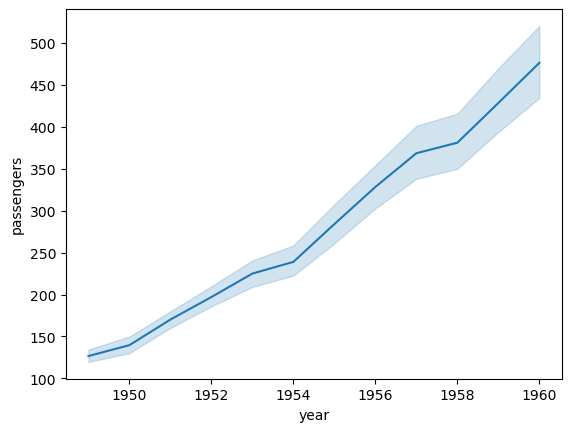

In [71]:
sns.lineplot(x='year', y='passengers', data=flights) # 두 수치형 데이터의 관계, 95% 신뢰구간

### 3. scatterplot() 산점도

In [73]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

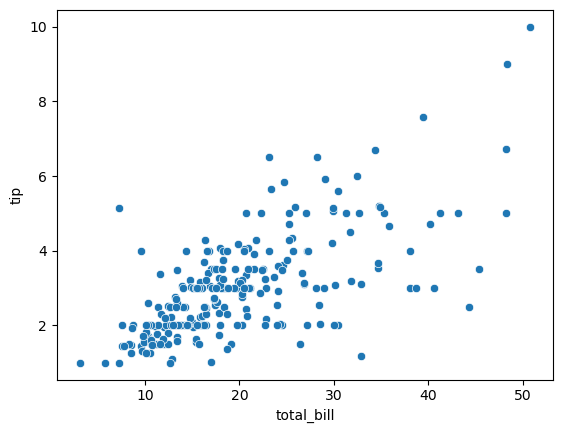

In [79]:
sns.scatterplot(x='total_bill', y='tip', data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

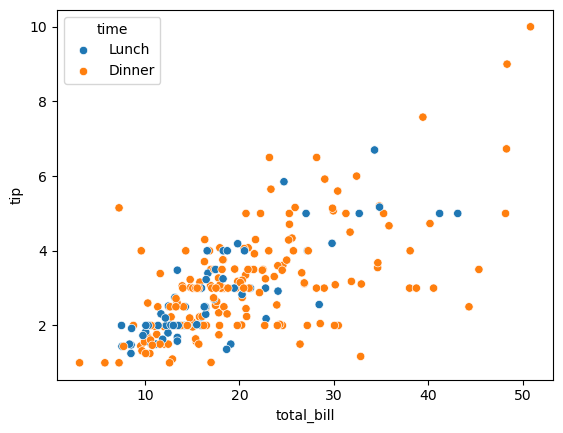

In [80]:
sns.scatterplot(x='total_bill', y='tip', data=tips, hue='time')

### 4. regplot() 회귀선을 포함한 산점도 그래프

<Axes: xlabel='total_bill', ylabel='tip'>

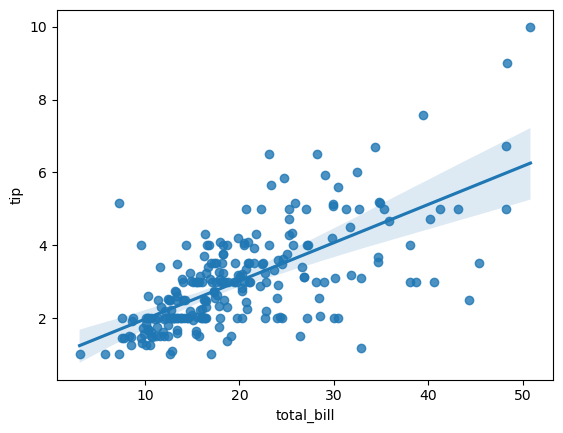

In [83]:
sns.regplot(x='total_bill', y='tip', data=tips, ci=99) # ci는 신뢰구간 설정